# Imports

In [4]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import kagglehub
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('playground-series-s6e8')

100%|██████████| 19.7M/19.7M [00:00<00:00, 124MB/s]

Extracting files...


In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
df_test = pd.read_csv(f'{path}/test.csv')
df_train = pd.read_csv(f'{path}/train.csv')

In [9]:
# df_test =  pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Smartphone Addiction/test.csv')
# df_train =  pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Smartphone Addiction/train.csv')

In [10]:
# df_test =  pd.read_csv('test.csv')
# df_train =  pd.read_csv('train.csv')

In [11]:
df_test['source'] = 'test'
df_train['source'] = 'train'

In [12]:
df = pd.concat(
    [df_train, df_test],
    ignore_index = True
)

In [13]:
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label,source
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1.0,train
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0.0,train
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0.0,train
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1.0,train
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1.0,train


# Info

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,987671.0,493835.000000,285116.203196,0.00,246917.50,493835.00,740752.50,987670.00
age,941604.0,26.613416,5.153219,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,859029.0,7.640836,2.722818,0.50,5.46,7.77,9.84,15.00
social_media_hours,806279.0,2.471096,1.316756,0.00,1.45,2.31,3.37,8.00
gaming_hours,801430.0,1.458793,0.934603,0.00,0.70,1.33,2.09,4.00
work_study_hours,908376.0,2.366673,1.258272,0.00,1.36,2.20,3.20,6.00
sleep_hours,920736.0,6.803552,1.234978,4.50,5.77,6.80,7.87,9.00
notifications_per_day,885866.0,145.851459,65.946264,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,881256.0,102.642749,48.122283,15.00,63.00,104.00,145.00,180.00
weekend_screen_time,824911.0,9.478291,2.856713,0.51,7.27,9.58,11.75,17.56


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987671 entries, 0 to 987670
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       987671 non-null  int64  
 1   age                      941604 non-null  float64
 2   daily_screen_time_hours  859029 non-null  float64
 3   social_media_hours       806279 non-null  float64
 4   gaming_hours             801430 non-null  float64
 5   work_study_hours         908376 non-null  float64
 6   sleep_hours              920736 non-null  float64
 7   notifications_per_day    885866 non-null  float64
 8   app_opens_per_day        881256 non-null  float64
 9   weekend_screen_time      824911 non-null  float64
 10  gender                   944425 non-null  object 
 11  stress_level             912897 non-null  object 
 12  academic_work_impact     917726 non-null  object 
 13  addicted_label           691369 non-null  float64
 14  sour

In [16]:
df.isna().sum()

,0
id,0
age,46067
daily_screen_time_hours,128642
social_media_hours,181392
gaming_hours,186241
work_study_hours,79295
sleep_hours,66935
notifications_per_day,101805
app_opens_per_day,106415
weekend_screen_time,162760


<Axes: xlabel='addicted_label', ylabel='count'>

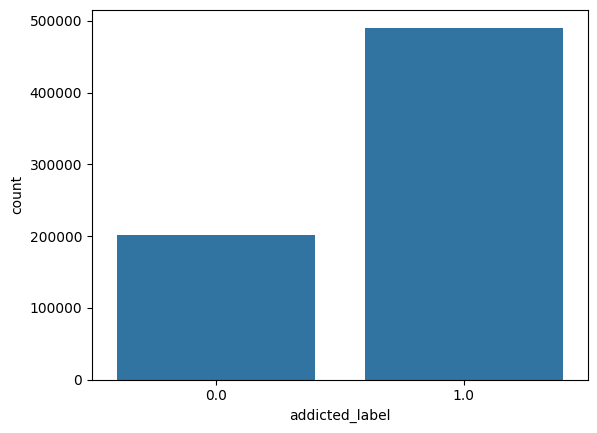

In [17]:
sns.countplot(
    data=df,
    x='addicted_label'
)

In [18]:
df['addicted_label'].value_counts(normalize=True)

,proportion
addicted_label,
1.0,0.709424
0.0,0.290576


In [19]:
df['id'].nunique()

987671

# EDA

<Axes: >

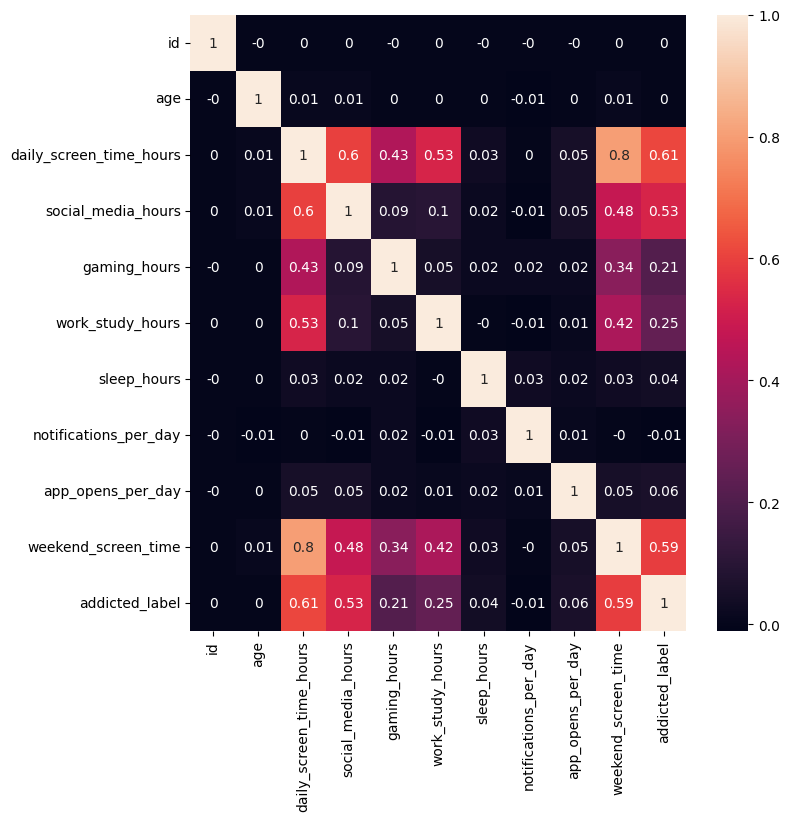

In [20]:
correlations = df[df['source']=='train'].select_dtypes(include='number').corr()

plt.figure(figsize=(8,8))
sns.heatmap(
    data=correlations.round(2),
    annot=True,
)

Text(0.5, 1.0, 'Age distribution by Addicted Label')

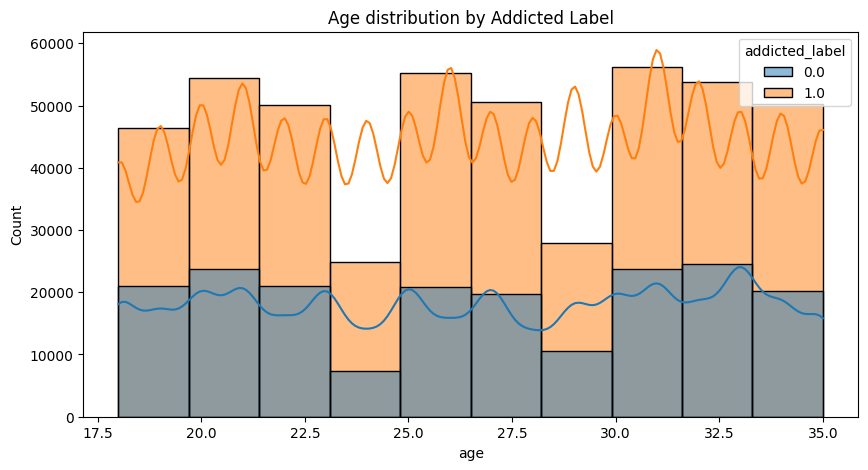

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='age',
    bins = 10,
    hue='addicted_label',
    kde=True
)
plt.title('Age distribution by Addicted Label')

Text(0.5, 1.0, 'Age distribution by Gender')

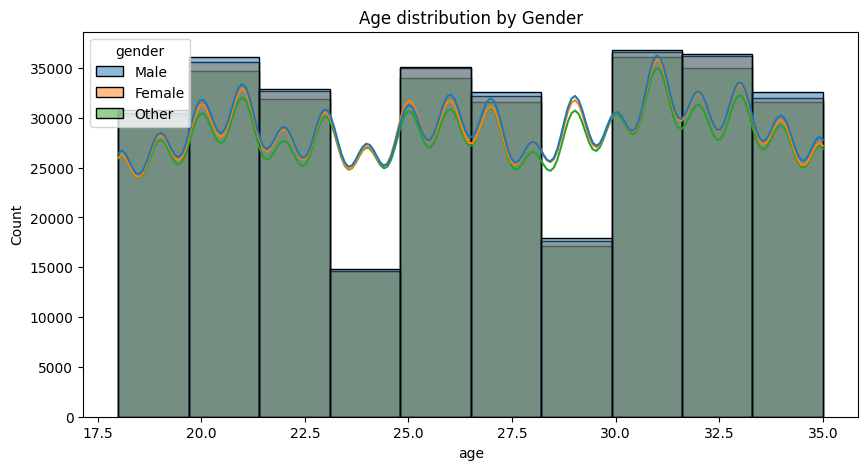

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='age',
    bins = 10,
    hue='gender',
    kde=True
)
plt.title('Age distribution by Gender')

Text(0.5, 1.0, 'Addcition Distribtuion by Age')

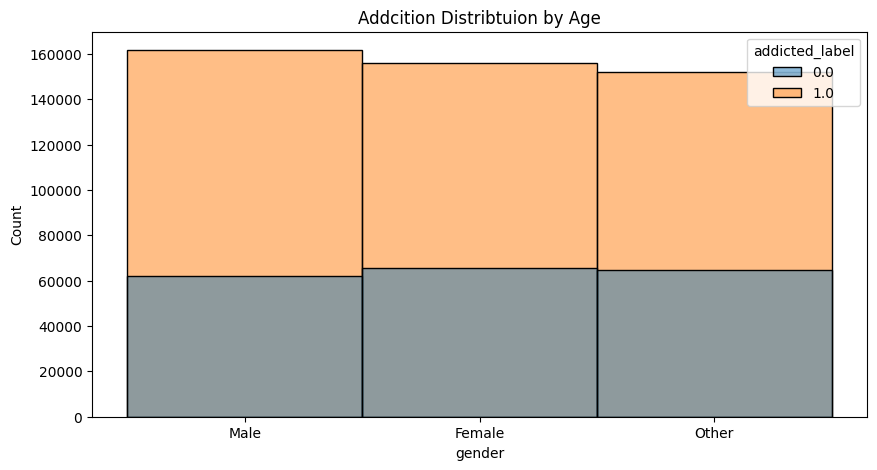

In [23]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='gender',
    bins = 10,
    hue='addicted_label'
)
plt.title('Addcition Distribtuion by Age')

## Missing Values

In [24]:
null_columns = (pd.DataFrame(df.isna().sum(),
             index=df.isna().sum().index,
             columns=['num_missing']
            ))
null_columns['pct_missing'] = (null_columns['num_missing'] / len(df)).round(2)
print(null_columns)

                         num_missing  pct_missing
id                                 0         0.00
age                            46067         0.05
daily_screen_time_hours       128642         0.13
social_media_hours            181392         0.18
gaming_hours                  186241         0.19
work_study_hours               79295         0.08
sleep_hours                    66935         0.07
notifications_per_day         101805         0.10
app_opens_per_day             106415         0.11
weekend_screen_time           162760         0.16
gender                         43246         0.04
stress_level                   74774         0.08
academic_work_impact           69945         0.07
addicted_label                296302         0.30
source                             0         0.00


In [25]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label',
       'source'],
      dtype='object')

In [26]:
for col in df.drop(columns=['id', 'source', 'addicted_label'], axis=1).columns:
    df[f'{col}_is_missing'] = df[col].isnull().astype(int)

# Feature Engineering

In [27]:
# Map academic work impact to 1 / 0

df['academic_work_impact'] = df['academic_work_impact'].map({'Yes': 1, 'No': 0})

# Training

In [28]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_validate, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [29]:
df.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,...,social_media_hours_is_missing,gaming_hours_is_missing,work_study_hours_is_missing,sleep_hours_is_missing,notifications_per_day_is_missing,app_opens_per_day_is_missing,weekend_screen_time_is_missing,gender_is_missing,stress_level_is_missing,academic_work_impact_is_missing
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,...,0,0,0,0,0,0,0,0,0,0
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,...,0,1,0,0,0,0,1,0,0,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,...,1,1,1,0,0,0,0,0,0,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,...,0,0,0,0,0,0,0,0,0,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,...,0,0,0,0,1,1,0,0,0,0


## Data Preparation

In [30]:
target = 'addicted_label'
drop_features = ['id', 'addicted_label', 'source']
numerical_features = [col for col in df.select_dtypes(include='number').columns if col not in ['addicted_label', 'id']]
categorical_features = ['gender', 'stress_level']

In [31]:
training_set = df[df['source'] == 'train']
testing_set = df[df['source'] == 'test'].drop(drop_features, axis=1)

In [32]:
X = training_set.drop(drop_features, axis=1)
y = training_set[target]

## Pipeline

In [33]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore',drop=None),categorical_features)
        # ('num', SimpleImputer(strategy='median'), numerical_features)
    ],
    remainder='passthrough'
)

In [34]:
xgb = XGBClassifier(
    n_estimators = 400,
    learning_rate = 0.05,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.8
)

In [35]:
model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', xgb)
])

## Cross Validation

In [36]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle=True
)

In [37]:
# scores = cross_validate(
#     estimator=model,
#     X=X,
#     y=y,
#     return_train_score=True,
#     cv=cv,
#     # n_jobs = 5,
#     scoring='roc_auc',
#     verbose=3
# )

In [38]:
# print(f"Train roc_auc: {scores.get('train_score').mean().round(5)} +- {scores.get('train_score').mean().round(5).std()}")
# print(f"Test roc_auc: {scores.get('test_score').mean().round(5)} +- {scores.get('test_score').mean().round(5).std()}")

## Hyperparameter Tuning

In [39]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 30.8 MB/s eta 0:00:00


In [40]:
import optuna

In [41]:
def objective(trial):
  params = {
      "max_depth": trial.suggest_int("max_depth", 3, 10),
      "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
      "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
      "subsample": trial.suggest_float("subsample", 0.5, 1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
      "gamma": trial.suggest_float("gamma", 0, 5.0),
      "reg_alpha": trial.suggest_float("reg_alpha", 0, 5.0),
      "reg_lambda": trial.suggest_float("reg_lambda", 0, 5.0),
  }

  #Model
  xgb = XGBClassifier(
      **params,
      device="cuda"
  )

  # Do cross val
  score = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

  # Return Score
  return score

In [ ]:
study = optuna.create_study(
    study_name = 'xgboost_study_cpu',
    direction = 'maximize'
)

study.optimize(
    func=objective,
    n_trials = 10,
    show_progress_bar=True,
    n_jobs = -1
)

best_params = study.best_params
print(f"\nBest Parameters: {best_params}")


[I 2026-08-14 21:11:41,203] A new study created in memory with name: xgboost_study_cpu


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
# for fold, (train_idx, val_idx) in enumerate(cv.split(X,y)):

#   X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#   y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#   print(f"Fold: {fold+1}")

## Fitting

In [ ]:
# model.fit(X, y)

In [ ]:
# feature_columns = model.named_steps['preprocess'].get_feature_names_out()
# importances = model.named_steps['clf'].feature_importances_

# plt.figure(figsize=(8,8))
# importances_df = pd.DataFrame({
#     'feature': feature_columns,
#     'importance': importances
# }).sort_values('importance', ascending=False)

# sns.barplot(
#     data=importances_df,
#     x='importance',
#     y='feature'
# )

# Submission

In [ ]:
results = model.predict_proba(testing_set)

In [ ]:
model.classes_

In [ ]:
results[:, 1]

In [ ]:
df_test['addicted_label'] = results[:, 1]
display(df_test[['id', 'addicted_label']].head())

In [ ]:
# df_test[['id', 'addicted_label']].to_csv('/content/drive/MyDrive/Kaggle Practice/Smartphone Addiction/submission_v1.csv', index=False)

In [ ]:
# df_test[['id', 'addicted_label']].to_csv('submission_v2.csv', index=False)